In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/adkat/Downloads/education_dataset (1).csv")
df.head()
from sklearn.feature_selection import VarianceThreshold



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              2000 non-null   int64  
 1   age                     2000 non-null   int64  
 2   study_hours_per_week    2000 non-null   float64
 3   attendance_rate         2000 non-null   float64
 4   homework_completion     2000 non-null   float64
 5   reading_score           2000 non-null   float64
 6   math_score              2000 non-null   float64
 7   science_score           2000 non-null   float64
 8   parent_education_level  2000 non-null   object 
 9   family_income           2000 non-null   float64
 10  student_ethnicity       2000 non-null   object 
 11  disability_status       2000 non-null   object 
 12  tutoring_support        2000 non-null   object 
 13  internet_access         2000 non-null   object 
 14  school_type             2000 non-null   

In [4]:
# Diagnostic cell - run inside the same notebook kernel
import sys, traceback

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("sys.path[0:6]:", sys.path[:6])

try:
    import sklearn
    print("scikit-learn import OK, version:", sklearn.__version__)
except Exception:
    print("scikit-learn import failed. Traceback:")
    traceback.print_exc()

import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install scikit-learn

Python executable: c:\Users\adkat\anaconda3\python.exe
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
sys.path[0:6]: ['c:\\Users\\adkat\\anaconda3\\python313.zip', 'c:\\Users\\adkat\\anaconda3\\DLLs', 'c:\\Users\\adkat\\anaconda3\\Lib', 'c:\\Users\\adkat\\anaconda3', '', 'c:\\Users\\adkat\\anaconda3\\Lib\\site-packages']
scikit-learn import OK, version: 1.6.1
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------------------- ---- 1.6/1.8 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 9.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1
    Uninstalling pip-25.1:
      Successfully uninstalled pip-25.1


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

numeric = df.select_dtypes(include=[np.number]).copy()
print("Numeric feature count:", numeric.shape[1])

numeric = numeric.fillna(numeric.mean())

variances = numeric.var(axis=0)
print("Smallest variances (ascending):")
print(variances.sort_values().head(20))

threshold = 0.0

selector = VarianceThreshold(threshold=threshold)
selector.fit(numeric)

mask = selector.get_support()
selected_cols = numeric.columns[mask]
removed_cols = numeric.columns[~mask]

print(f"Kept {len(selected_cols)} / {numeric.shape[1]} numeric features")
print("Removed columns:", list(removed_cols))

numeric_reduced = numeric.loc[:, selected_cols]

non_numeric = df.select_dtypes(exclude=[np.number]).reset_index(drop=True)
numeric_reduced = numeric_reduced.reset_index(drop=True)
df_reduced = pd.concat([non_numeric, numeric_reduced], axis=1)

Numeric feature count: 14
Smallest variances (ascending):
bus_arrival_time        6.701101e-01
num_siblings            1.228550e+00
gaming_hours            1.443016e+00
age                     2.047451e+00
social_media_hours      2.271643e+00
study_hours_per_week    8.853571e+00
final_exam_score        5.426186e+01
reading_score           1.105554e+02
science_score           1.184065e+02
attendance_rate         1.321353e+02
math_score              1.340775e+02
homework_completion     2.066884e+02
student_id              3.335000e+05
family_income           2.318106e+08
dtype: float64
Kept 14 / 14 numeric features
Removed columns: []


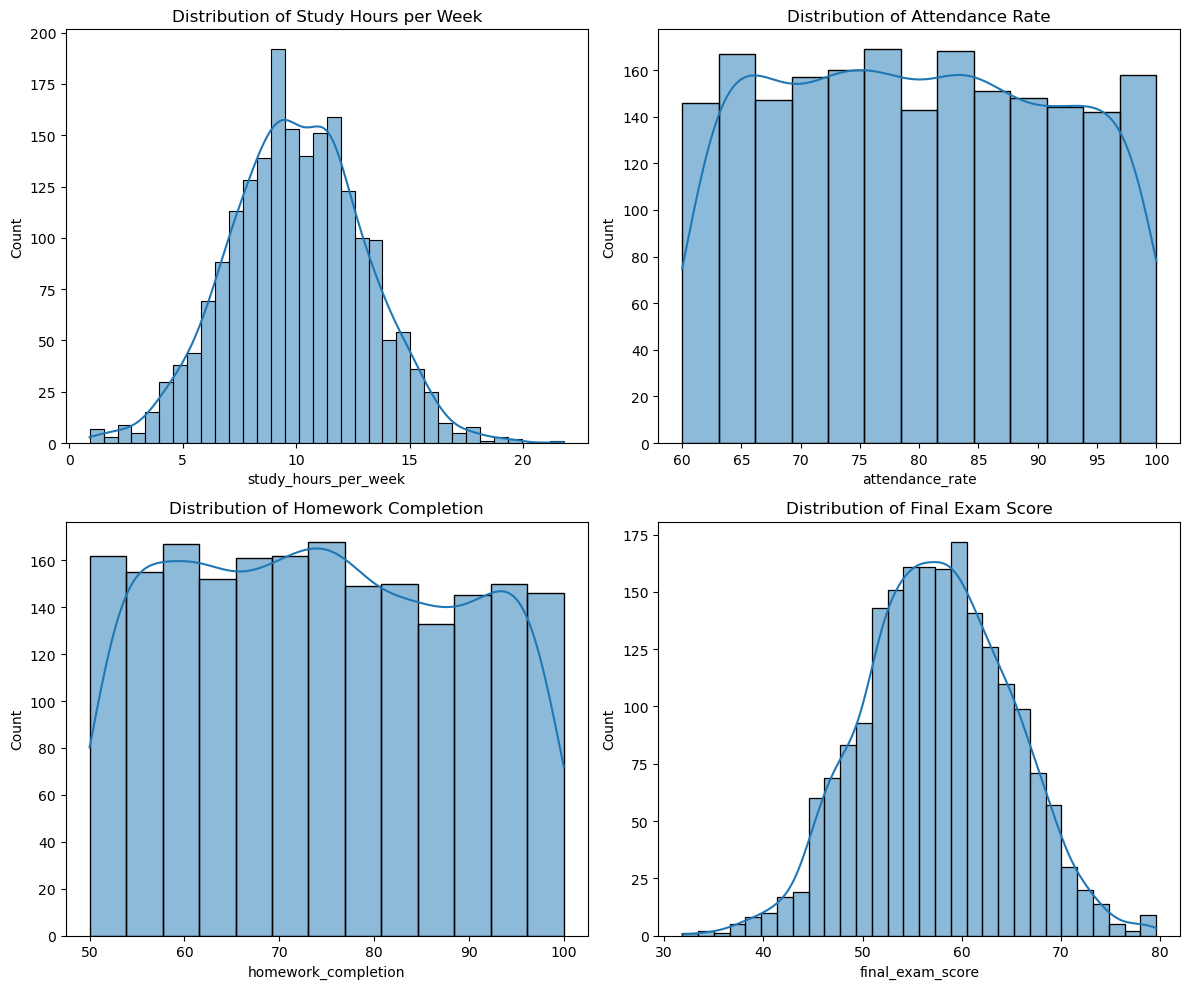

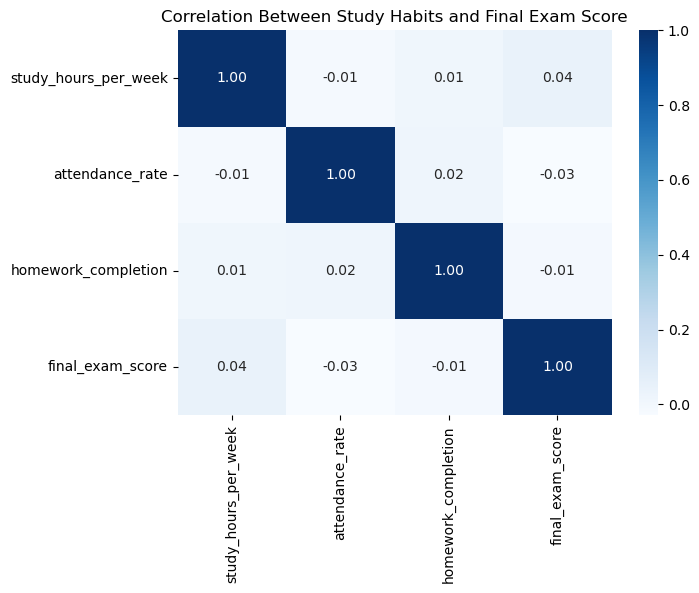

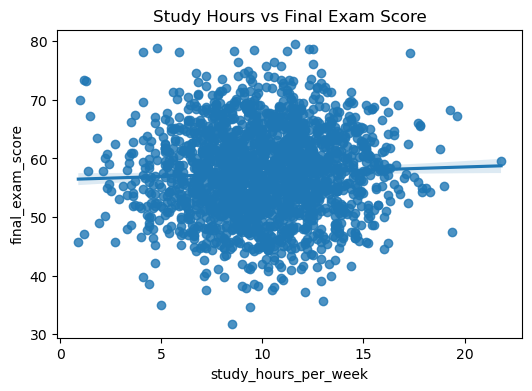

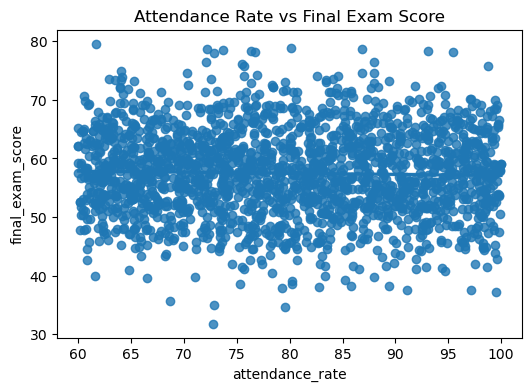

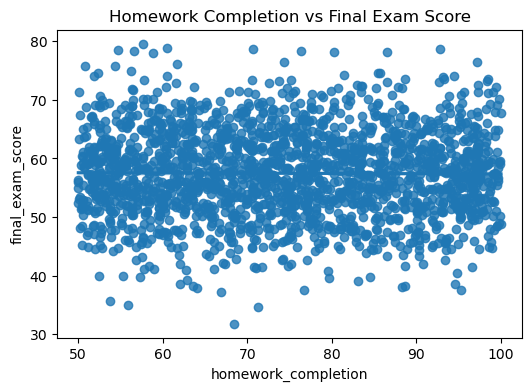

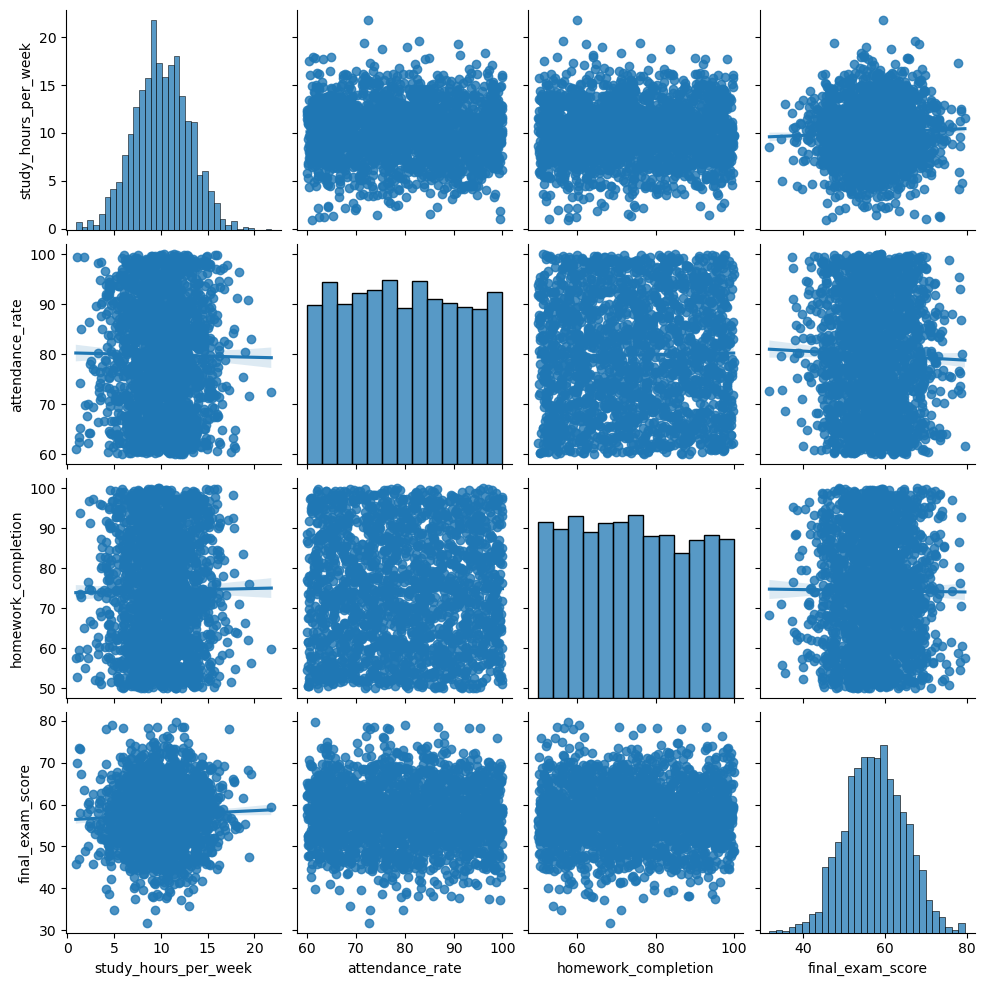

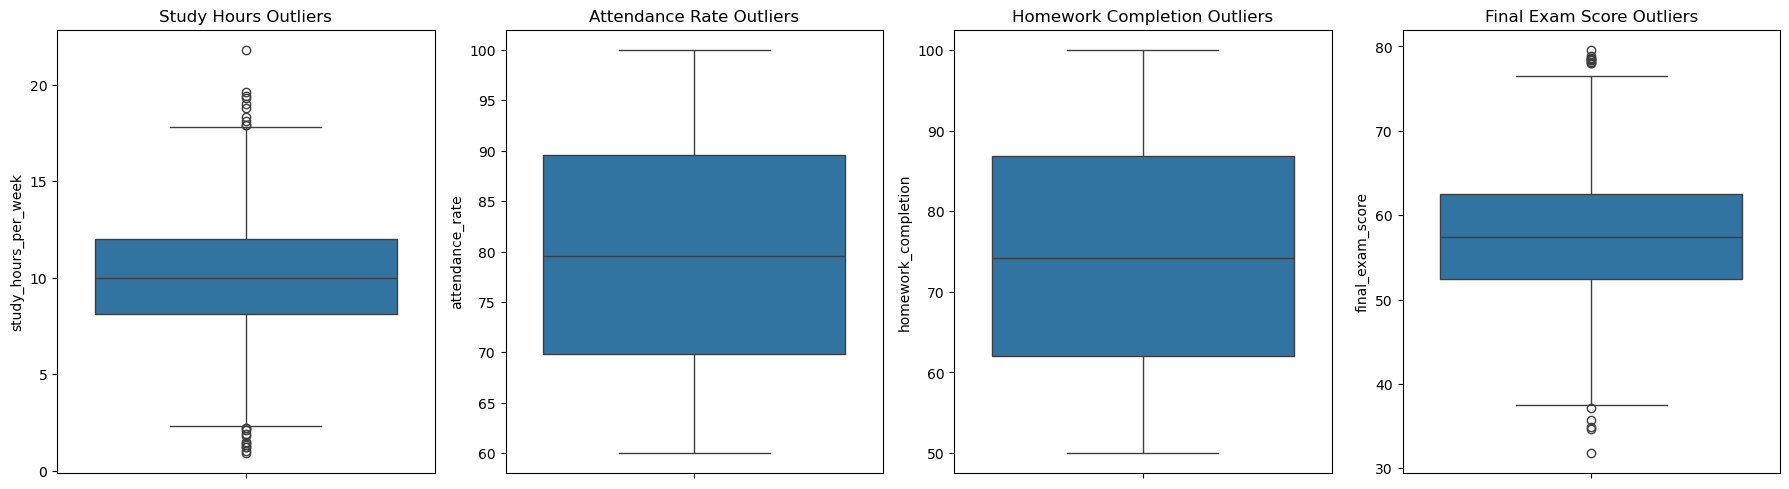

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



eda_df = df[['study_hours_per_week','attendance_rate','homework_completion','final_exam_score']]
eda_df.describe()

fig, axes = plt.subplots(2, 2, figsize=(12,10))
sns.histplot(eda_df['study_hours_per_week'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribution of Study Hours per Week")
sns.histplot(eda_df['attendance_rate'], kde=True, ax=axes[0,1])
axes[0,1].set_title("Distribution of Attendance Rate")
sns.histplot(eda_df['homework_completion'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Distribution of Homework Completion")
sns.histplot(eda_df['final_exam_score'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Distribution of Final Exam Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(eda_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Study Habits and Final Exam Score")
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(data=eda_df, x='study_hours_per_week', y='final_exam_score')
plt.title("Study Hours vs Final Exam Score")
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(data=eda_df, x='attendance_rate', y='final_exam_score')
plt.title("Attendance Rate vs Final Exam Score")
plt.show()

plt.figure(figsize=(6,4))
sns.regplot(data=eda_df, x='homework_completion', y='final_exam_score')
plt.title("Homework Completion vs Final Exam Score")
plt.show()

sns.pairplot(eda_df, kind="reg")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18,5))
sns.boxplot(y=eda_df['study_hours_per_week'], ax=axes[0])
axes[0].set_title("Study Hours Outliers")
sns.boxplot(y=eda_df['attendance_rate'], ax=axes[1])
axes[1].set_title("Attendance Rate Outliers")
sns.boxplot(y=eda_df['homework_completion'], ax=axes[2])
axes[2].set_title("Homework Completion Outliers")
sns.boxplot(y=eda_df['final_exam_score'], ax=axes[3])
axes[3].set_title("Final Exam Score Outliers")
plt.tight_layout()
plt.show()


In [7]:
# Step A: encode categorical columns so the model can use them
# Run this after any previous cleaning (e.g., df_reduced or df)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns detected:", cat_cols)

# If there are no categorical columns this will do nothing
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# quick check
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Categorical columns detected: ['parent_education_level', 'student_ethnicity', 'disability_status', 'tutoring_support', 'internet_access', 'school_type', 'region', 'locker_number', 'favorite_subject', 'passed_course', 'college_admission']
Shape before encoding: (2000, 25)
Shape after encoding: (2000, 836)
